# SMHI 5 core-Parameter Data Exploration

This notebook explores the downloaded SMHI meteorological data with 13 parameters:
- **snow**: Snow depth (m)
- **precip**: Precipitation (mm)
- **wind**: Wind speed (m/s)
- **humidity**: Relative humidity (%)

Plus metadata: temp, temp_min, temp_max (if available)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load and Initial Inspection

In [2]:
# Load the data
df = pd.read_csv('../data/raw/smhi_5core_params.csv', parse_dates=['date'])

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of Stations: {df['station_id'].nunique()}")

Dataset Shape: 1,616,151 rows x 10 columns

Memory Usage: 232.57 MB

Date Range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00
Number of Stations: 659


In [3]:
# Display first few rows
df.head(10)

,date,station_id,station_name,latitude,longitude,elevation,snow,precip,wind,humidity
0,2015-01-01,188800,Abisko,68.3538,18.8166,393.38,0.71,NaN,NaN,NaN
1,2015-01-02,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN
2,2015-01-05,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN
3,2015-01-07,188800,Abisko,68.3538,18.8166,393.38,0.69,NaN,NaN,NaN
4,2015-01-08,188800,Abisko,68.3538,18.8166,393.38,0.67,NaN,NaN,NaN
5,2015-01-09,188800,Abisko,68.3538,18.8166,393.38,0.72,NaN,NaN,NaN
6,2015-01-12,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN
7,2015-01-13,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN
8,2015-01-14,188800,Abisko,68.3538,18.8166,393.38,0.64,NaN,NaN,NaN
9,2015-01-15,188800,Abisko,68.3538,18.8166,393.38,0.63,NaN,NaN,NaN


In [4]:
# Column data types
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
date            datetime64[ns]
station_id               int64
station_name            object
latitude               float64
longitude              float64
elevation              float64
snow                   float64
precip                 float64
wind                   float64
humidity               float64
dtype: object


In [5]:
# Basic statistics
df.describe()

,date,station_id,latitude,longitude,elevation,snow,precip,wind,humidity
count,1616151,1.616151e+06,1.616151e+06,1.616151e+06,1.616151e+06,1.616151e+06,5533.000000,25585.000000,8847.000000
mean,2020-06-05 13:01:29.218643200,1.057313e+05,6.048170e+01,1.591270e+01,1.626532e+02,8.009438e-02,1.584981,4.123071,4.729502
min,2015-01-01 00:00:00,5.223000e+04,5.535940e+01,1.117870e+01,-1.069000e+00,-2.000000e-02,0.000000,0.000000,0.000000
25%,2017-10-06 00:00:00,7.623000e+04,5.779940e+01,1.386070e+01,4.565200e+01,0.000000e+00,0.000000,2.204167,3.555556
50%,2020-06-21 00:00:00,9.635000e+04,5.953390e+01,1.553040e+01,1.261320e+02,0.000000e+00,0.000000,3.387500,4.833333
75%,2023-01-28 00:00:00,1.340000e+05,6.316110e+01,1.741460e+01,2.401700e+02,0.000000e+00,1.300000,5.358333,6.047619
max,2025-10-01 00:00:00,1.937300e+05,6.880320e+01,2.411200e+01,8.040000e+02,2.290000e+00,76.300000,20.600000,9.000000
std,NaN,3.504314e+04,3.315069e+00,2.718492e+00,1.454265e+02,2.001285e-01,3.878356,2.676332,1.845116


## 2. Missing Data Analysis (Critical!)

This is crucial - not all stations measure all parameters.

In [6]:
# Define parameter columns (excluding metadata)
metadata_cols = ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation']
param_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Parameter columns: {param_cols}")
print(f"\nNumber of parameters: {len(param_cols)}")

Parameter columns: ['snow', 'precip', 'wind', 'humidity']

Number of parameters: 4


In [7]:
# Missing values count and percentage
missing_stats = pd.DataFrame({
    'Total Records': len(df),
    'Non-Null Count': df[param_cols].notna().sum(),
    'Null Count': df[param_cols].isna().sum(),
    'Null %': (df[param_cols].isna().sum() / len(df) * 100).round(2),
    'Non-Zero Count': (df[param_cols] != 0).sum(),
    'Zero Count': (df[param_cols] == 0).sum(),
})

missing_stats['Coverage %'] = (100 - missing_stats['Null %']).round(2)
missing_stats = missing_stats.sort_values('Coverage %', ascending=False)

print("=" * 80)
print("PARAMETER DATA AVAILABILITY")
print("=" * 80)
print(missing_stats)

PARAMETER DATA AVAILABILITY
          Total Records  Non-Null Count  Null Count  Null %  Non-Zero Count  Zero Count  Coverage %
snow            1616151         1616151           0    0.00          393288     1222863      100.00
wind            1616151           25585     1590566   98.42         1616139          12        1.58
humidity        1616151            8847     1607304   99.45         1616057          94        0.55
precip          1616151            5533     1610618   99.66         1613275        2876        0.34


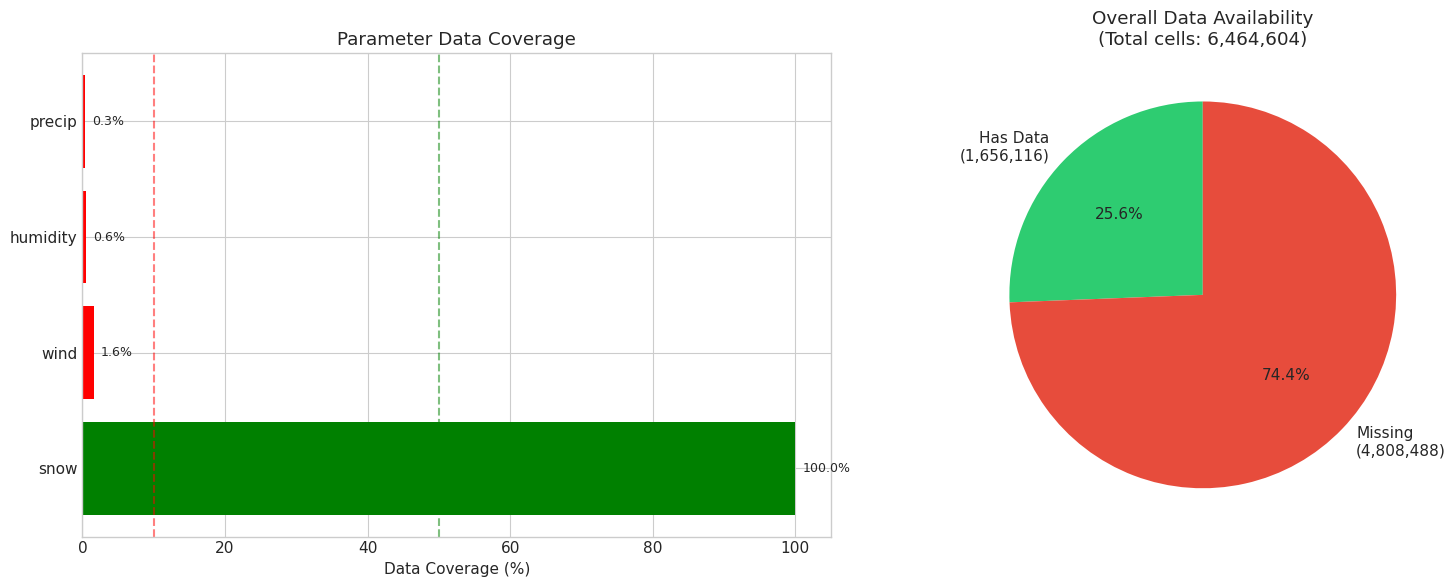

In [8]:
# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of coverage
colors = ['green' if x > 50 else 'orange' if x > 10 else 'red' for x in missing_stats['Coverage %']]
axes[0].barh(missing_stats.index, missing_stats['Coverage %'], color=colors)
axes[0].set_xlabel('Data Coverage (%)')
axes[0].set_title('Parameter Data Coverage')
axes[0].axvline(x=50, color='green', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
for i, (idx, row) in enumerate(missing_stats.iterrows()):
    axes[0].text(row['Coverage %'] + 1, i, f"{row['Coverage %']:.1f}%", va='center', fontsize=9)

# Pie chart of overall data availability
total_cells = len(df) * len(param_cols)
non_null_cells = df[param_cols].notna().sum().sum()
null_cells = total_cells - non_null_cells

axes[1].pie([non_null_cells, null_cells], 
            labels=[f'Has Data\n({non_null_cells:,})', f'Missing\n({null_cells:,})'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title(f'Overall Data Availability\n(Total cells: {total_cells:,})')

plt.tight_layout()
plt.show()

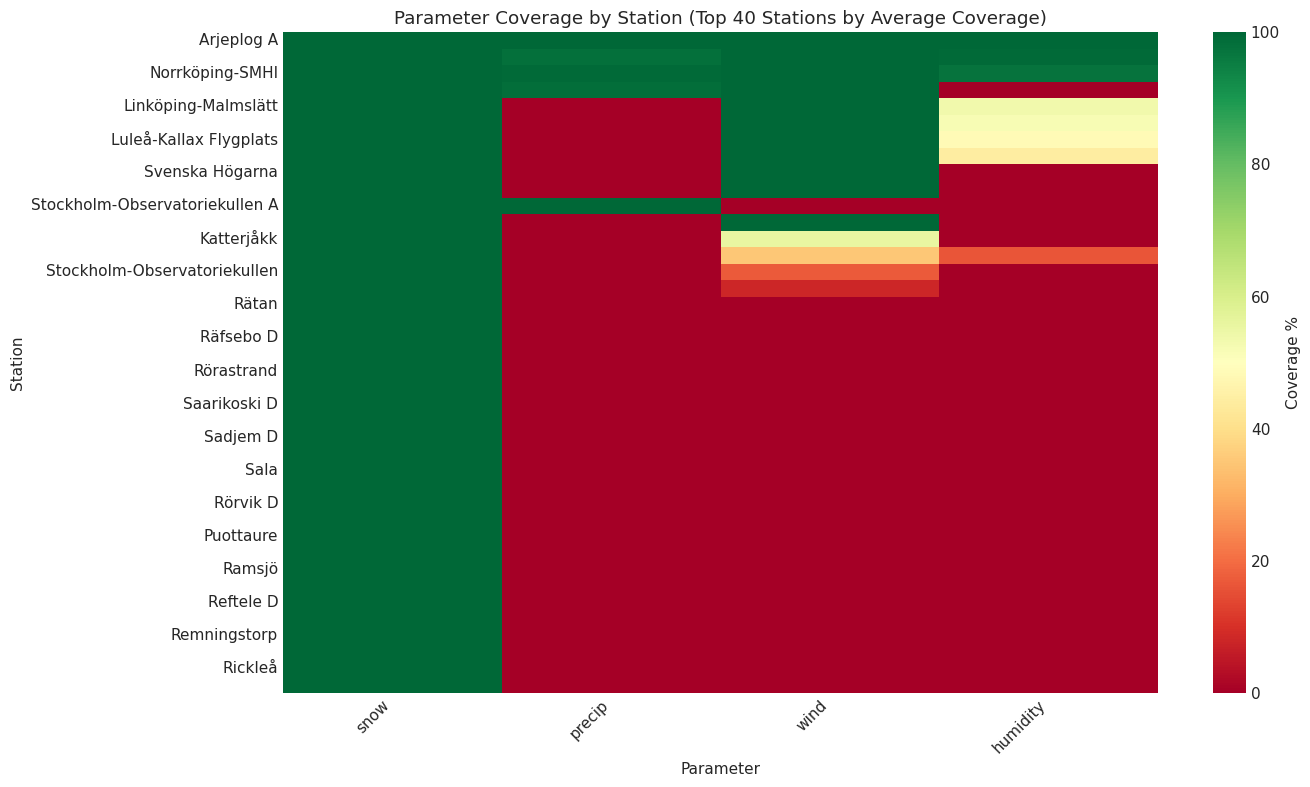

In [9]:
# Heatmap of missing data by parameter
fig, ax = plt.subplots(figsize=(14, 8))

# Sample data for visualization (too many rows for full heatmap)
sample_stations = df['station_name'].unique()[:30]
sample_df = df[df['station_name'].isin(sample_stations)]

# Create pivot table of data availability by station
station_coverage = df.groupby('station_name')[param_cols].apply(lambda x: x.notna().mean() * 100)
station_coverage_sorted = station_coverage.loc[station_coverage.mean(axis=1).sort_values(ascending=False).index]

# Show top 40 stations
sns.heatmap(station_coverage_sorted.head(40), annot=False, cmap='RdYlGn', 
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Coverage %'})
ax.set_title('Parameter Coverage by Station (Top 40 Stations by Average Coverage)')
ax.set_xlabel('Parameter')
ax.set_ylabel('Station')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Check for Zero Values vs Actual Data

In [10]:
# Analyze zero vs non-zero values (excluding NaN)
print("=" * 80)
print("ZERO VALUE ANALYSIS (Are parameters actually zero or missing?)")
print("=" * 80)

for col in param_cols:
    non_null = df[col].notna()
    if non_null.sum() > 0:
        non_null_data = df.loc[non_null, col]
        zero_count = (non_null_data == 0).sum()
        non_zero_count = (non_null_data != 0).sum()
        zero_pct = zero_count / len(non_null_data) * 100
        
        print(f"\n{col}:")
        print(f"  Non-null records: {len(non_null_data):,}")
        print(f"  Zero values: {zero_count:,} ({zero_pct:.1f}%)")
        print(f"  Non-zero values: {non_zero_count:,} ({100-zero_pct:.1f}%)")
        if len(non_null_data) > 0:
            print(f"  Range: [{non_null_data.min():.4f}, {non_null_data.max():.4f}]")
            print(f"  Mean: {non_null_data.mean():.4f}")
    else:
        print(f"\n{col}: NO DATA (all values are NaN)")

ZERO VALUE ANALYSIS (Are parameters actually zero or missing?)

snow:
  Non-null records: 1,616,151
  Zero values: 1,222,863 (75.7%)
  Non-zero values: 393,288 (24.3%)
  Range: [-0.0200, 2.2900]
  Mean: 0.0801

precip:
  Non-null records: 5,533
  Zero values: 2,876 (52.0%)
  Non-zero values: 2,657 (48.0%)
  Range: [0.0000, 76.3000]
  Mean: 1.5850

wind:
  Non-null records: 25,585
  Zero values: 12 (0.0%)
  Non-zero values: 25,573 (100.0%)
  Range: [0.0000, 20.6000]
  Mean: 4.1231

humidity:
  Non-null records: 8,847
  Zero values: 94 (1.1%)
  Non-zero values: 8,753 (98.9%)
  Range: [0.0000, 9.0000]
  Mean: 4.7295


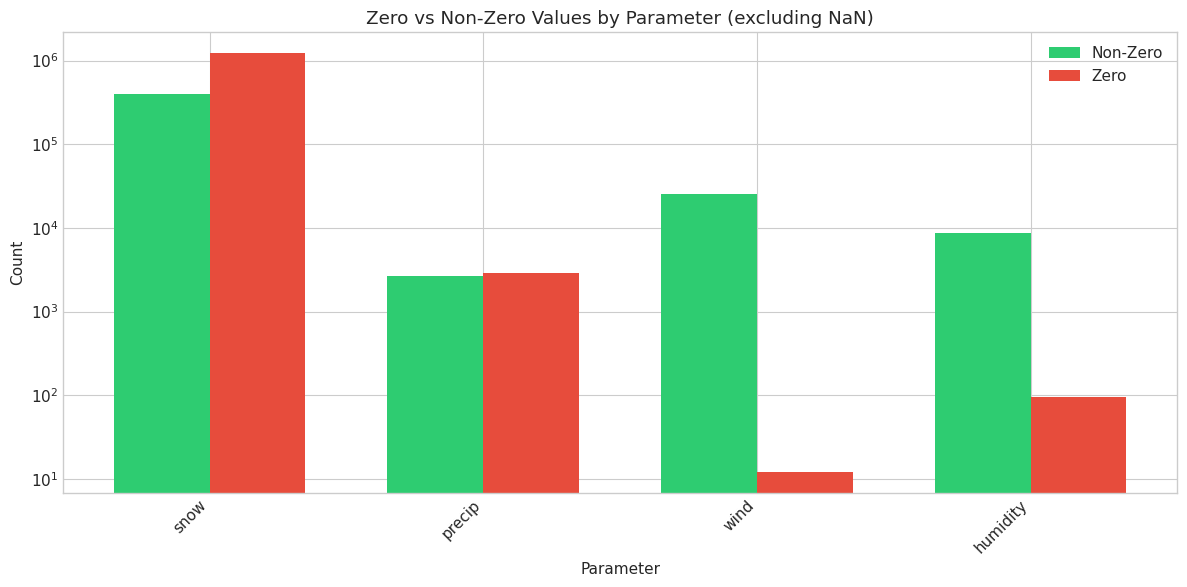

In [11]:
# Visual summary of zero values
zero_analysis = []
for col in param_cols:
    non_null = df[col].notna()
    if non_null.sum() > 0:
        non_null_data = df.loc[non_null, col]
        zero_count = (non_null_data == 0).sum()
        non_zero_count = (non_null_data != 0).sum()
        zero_analysis.append({
            'Parameter': col,
            'Total Records': len(non_null_data),
            'Zero Values': zero_count,
            'Non-Zero Values': non_zero_count,
            'Zero %': zero_count / len(non_null_data) * 100 if len(non_null_data) > 0 else 0
        })

zero_df = pd.DataFrame(zero_analysis)
if len(zero_df) > 0:
    zero_df = zero_df.set_index('Parameter')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(zero_df))
    width = 0.35
    
    bars1 = ax.bar([i - width/2 for i in x], zero_df['Non-Zero Values'], width, label='Non-Zero', color='#2ecc71')
    bars2 = ax.bar([i + width/2 for i in x], zero_df['Zero Values'], width, label='Zero', color='#e74c3c')
    
    ax.set_xlabel('Parameter')
    ax.set_ylabel('Count')
    ax.set_title('Zero vs Non-Zero Values by Parameter (excluding NaN)')
    ax.set_xticks(x)
    ax.set_xticklabels(zero_df.index, rotation=45, ha='right')
    ax.legend()
    ax.set_yscale('log')  # Log scale for better visibility
    
    plt.tight_layout()
    plt.show()

## 4. Station Analysis

In [12]:
# Station statistics
station_stats = df.groupby(['station_id', 'station_name', 'latitude', 'longitude', 'elevation']).agg({
    'date': ['min', 'max', 'count'],
    'snow': 'count'
}).reset_index()

station_stats.columns = ['station_id', 'station_name', 'latitude', 'longitude', 'elevation', 
                         'first_date', 'last_date', 'total_records', 'snow_records']

print(f"Total Stations: {len(station_stats)}")
print(f"\nStations by record count:")
print(station_stats.sort_values('total_records', ascending=False).head(20))

Total Stations: 659

Stations by record count:
     station_id    station_name  latitude  longitude  elevation first_date  last_date  total_records  snow_records
643      182800    Saittarova D   67.3369    22.2308    238.200 2015-01-01 2025-10-01           3927          3927
607      167790   Svartberget D   66.3227    17.3173    440.300 2015-01-01 2025-10-01           3927          3927
71        65500      Orrefors D   56.8213    15.6982    174.688 2015-01-01 2025-10-01           3927          3927
236       86320   Östra Husby D   58.5373    16.5611     26.117 2015-01-01 2025-10-01           3927          3927
626      173760    Kypasjärvi D   66.1920    23.2263     80.232 2015-01-01 2025-10-01           3927          3927
412      113410         Särna D   61.6909    13.1827    425.000 2015-01-01 2025-10-01           3927          3927
379      106040       Brovallen   60.0989    16.3026    100.154 2015-01-01 2025-10-01           3927          3927
369      105250    Stora Skedvi  

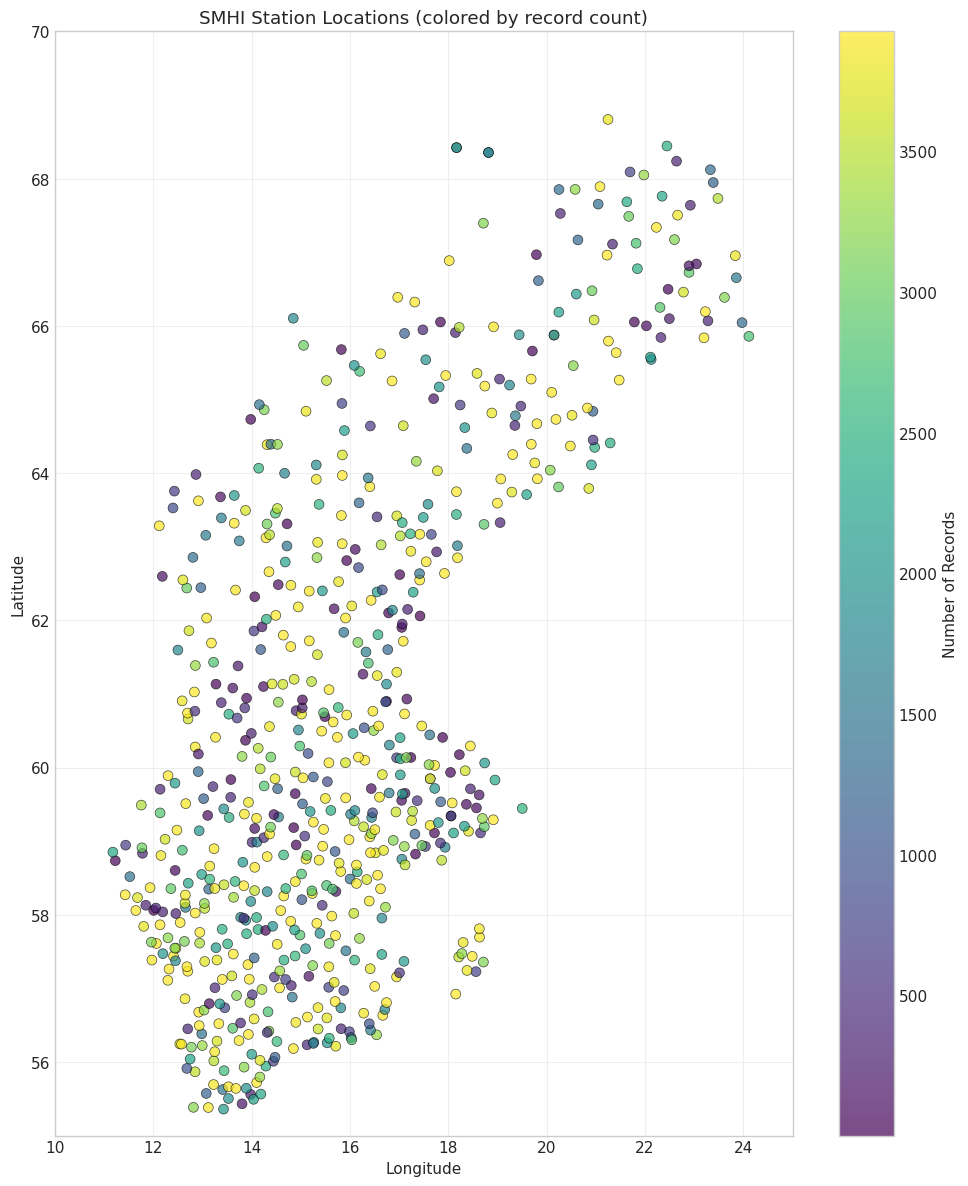

In [13]:
# Map of station locations
fig, ax = plt.subplots(figsize=(10, 12))

# Color by number of records
scatter = ax.scatter(station_stats['longitude'], station_stats['latitude'], 
                     c=station_stats['total_records'], cmap='viridis', 
                     s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.colorbar(scatter, ax=ax, label='Number of Records')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SMHI Station Locations (colored by record count)')
ax.grid(True, alpha=0.3)

# Add Sweden approximate boundary
ax.set_xlim(10, 25)
ax.set_ylim(55, 70)

plt.tight_layout()
plt.show()

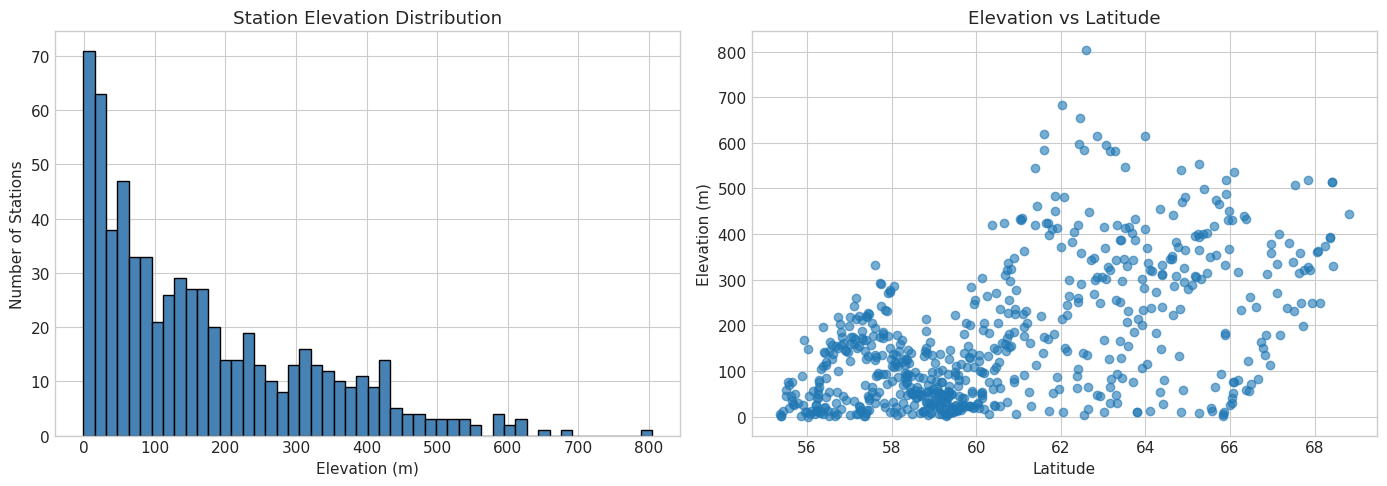

In [14]:
# Elevation distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of elevations
station_stats['elevation'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Elevation (m)')
axes[0].set_ylabel('Number of Stations')
axes[0].set_title('Station Elevation Distribution')

# Elevation vs Latitude
axes[1].scatter(station_stats['latitude'], station_stats['elevation'], alpha=0.6)
axes[1].set_xlabel('Latitude')
axes[1].set_ylabel('Elevation (m)')
axes[1].set_title('Elevation vs Latitude')

plt.tight_layout()
plt.show()

## 5. Temporal Analysis

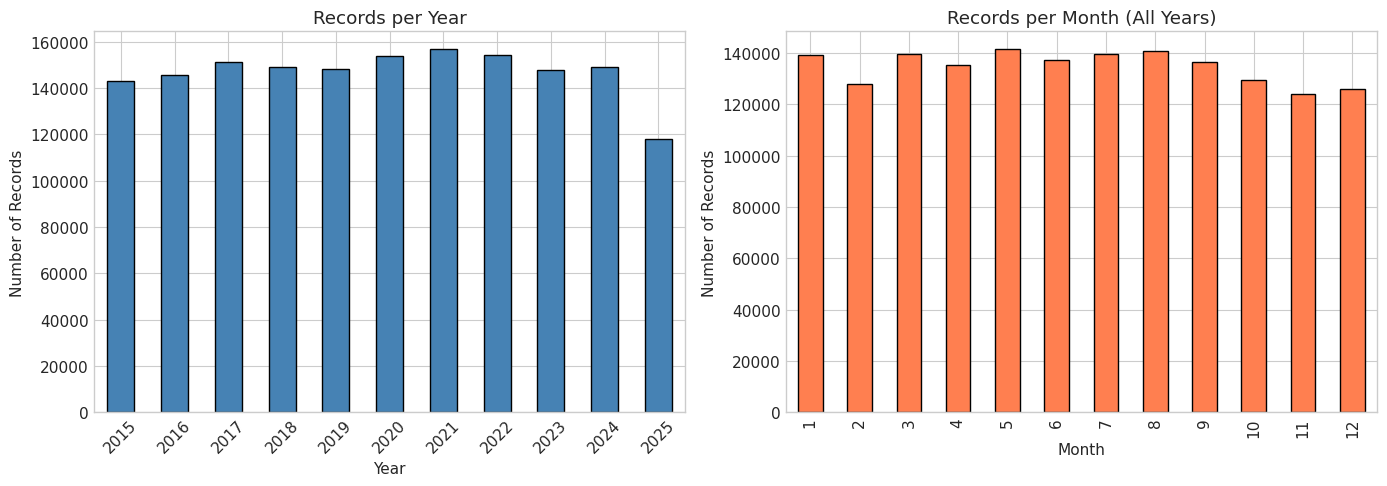

In [15]:
# Add temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

# Records per year
yearly_counts = df.groupby('year').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Records')
axes[0].set_title('Records per Year')
axes[0].tick_params(axis='x', rotation=45)

# Records per month
monthly_counts = df.groupby('month').size()
monthly_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Records')
axes[1].set_title('Records per Month (All Years)')

plt.tight_layout()
plt.show()

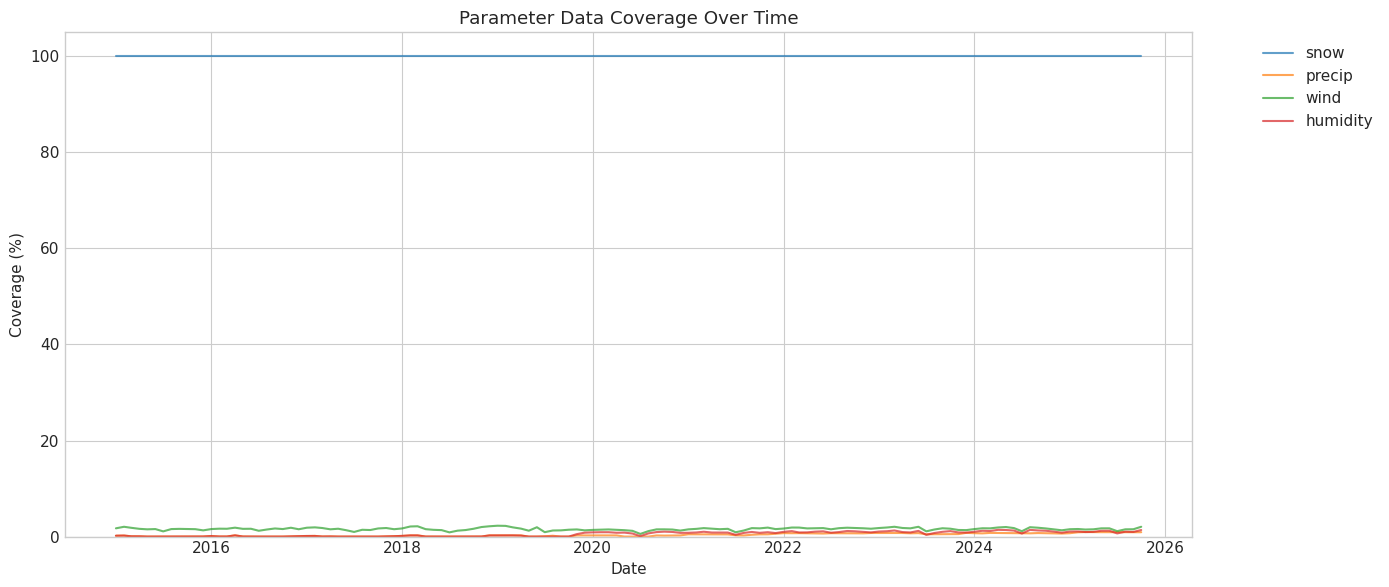

In [16]:
# Data coverage over time for each parameter
fig, ax = plt.subplots(figsize=(14, 6))

for col in param_cols:
    monthly_coverage = df.groupby([df['date'].dt.to_period('M')])[col].apply(lambda x: x.notna().mean() * 100)
    monthly_coverage.index = monthly_coverage.index.to_timestamp()
    ax.plot(monthly_coverage.index, monthly_coverage.values, label=col, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Coverage (%)')
ax.set_title('Parameter Data Coverage Over Time')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## 6. Snow Depth Analysis (Primary Target)

In [17]:
# Filter to snow data only
snow_df = df[df['snow'].notna()].copy()
print(f"Records with snow data: {len(snow_df):,} ({len(snow_df)/len(df)*100:.1f}%)")

# Convert snow from meters to cm for easier interpretation
snow_df['snow_cm'] = snow_df['snow'] * 100

print(f"\nSnow Depth Statistics (cm):")
print(snow_df['snow_cm'].describe())

Records with snow data: 1,616,151 (100.0%)

Snow Depth Statistics (cm):
count    1.616151e+06
mean     8.009438e+00
std      2.001285e+01
min     -2.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.290000e+02
Name: snow_cm, dtype: float64


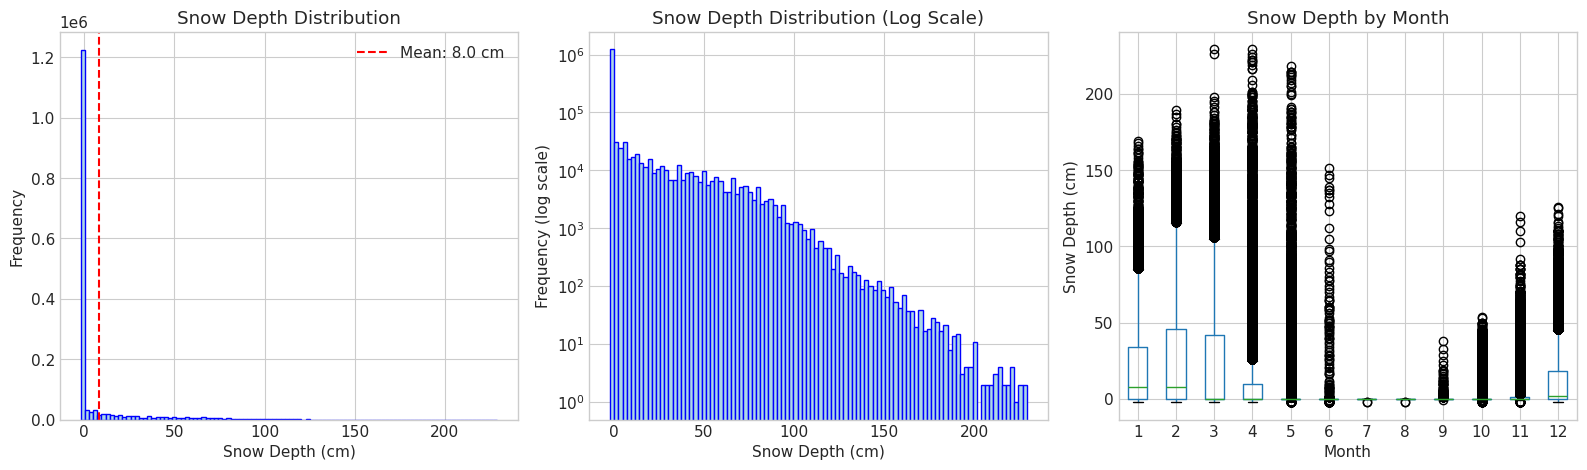

In [18]:
# Snow depth distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
snow_df['snow_cm'].hist(bins=100, ax=axes[0], color='lightblue', edgecolor='blue')
axes[0].set_xlabel('Snow Depth (cm)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Snow Depth Distribution')
axes[0].axvline(snow_df['snow_cm'].mean(), color='red', linestyle='--', label=f'Mean: {snow_df["snow_cm"].mean():.1f} cm')
axes[0].legend()

# Log scale histogram (to see rare deep snow events)
snow_df['snow_cm'].hist(bins=100, ax=axes[1], color='lightblue', edgecolor='blue')
axes[1].set_xlabel('Snow Depth (cm)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Snow Depth Distribution (Log Scale)')
axes[1].set_yscale('log')

# Box plot by month
snow_df.boxplot(column='snow_cm', by='month', ax=axes[2])
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Snow Depth (cm)')
axes[2].set_title('Snow Depth by Month')
plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

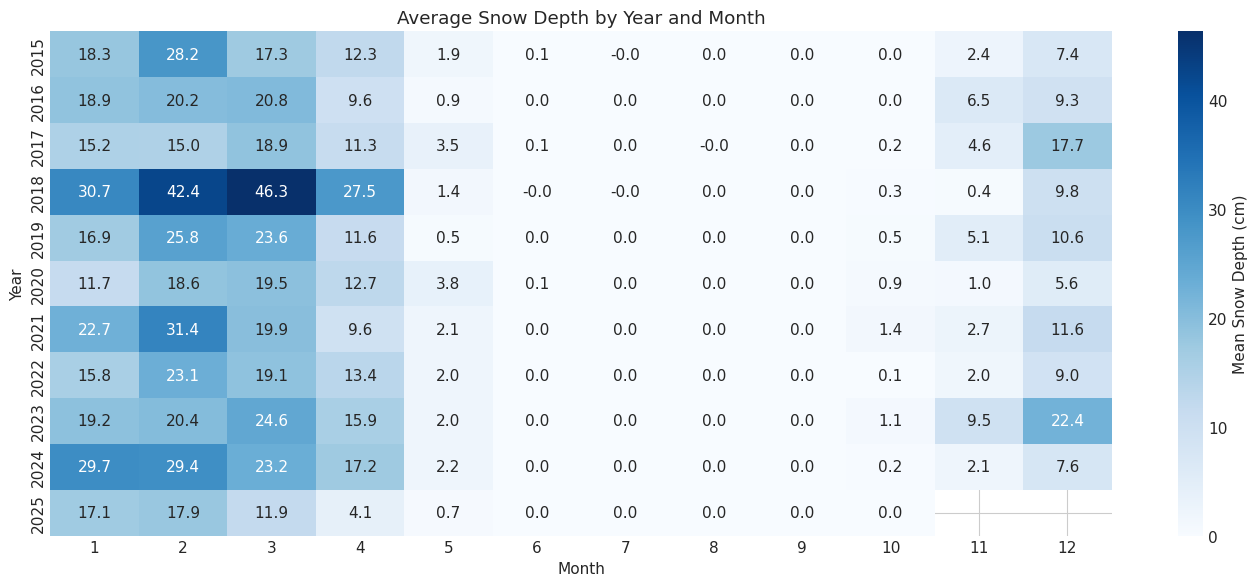

In [19]:
# Average snow depth by month and year
monthly_snow = snow_df.groupby(['year', 'month'])['snow_cm'].mean().unstack()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(monthly_snow, annot=True, fmt='.1f', cmap='Blues', ax=ax, cbar_kws={'label': 'Mean Snow Depth (cm)'})
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title('Average Snow Depth by Year and Month')
plt.tight_layout()
plt.show()

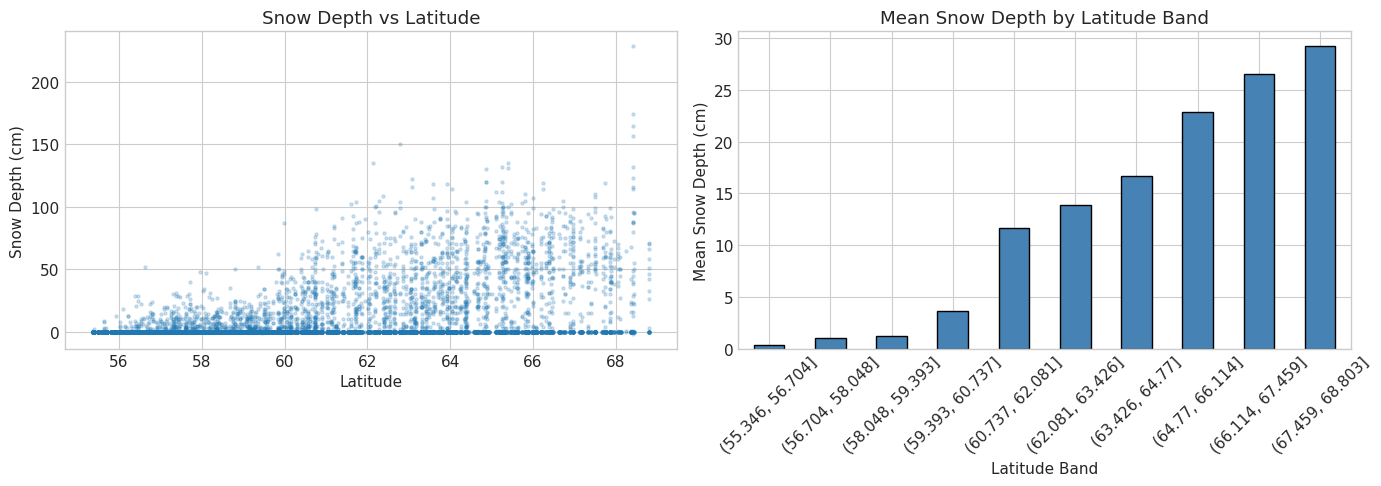

In [20]:
# Snow depth by latitude (north vs south Sweden)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sample = snow_df.sample(min(10000, len(snow_df)))  # Sample for performance
axes[0].scatter(sample['latitude'], sample['snow_cm'], alpha=0.2, s=5)
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel('Snow Depth (cm)')
axes[0].set_title('Snow Depth vs Latitude')

# Mean snow depth by latitude bands
snow_df['lat_band'] = pd.cut(snow_df['latitude'], bins=10)
lat_snow = snow_df.groupby('lat_band')['snow_cm'].mean()
lat_snow.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Latitude Band')
axes[1].set_ylabel('Mean Snow Depth (cm)')
axes[1].set_title('Mean Snow Depth by Latitude Band')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

In [21]:
# Correlation matrix for parameters with sufficient data
# Only include columns with > 10% coverage
sufficient_cols = [col for col in param_cols if df[col].notna().mean() > 0.10]

if len(sufficient_cols) > 1:
    corr_matrix = df[sufficient_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix (Parameters with >10% coverage)')
    plt.tight_layout()
    plt.show()
else:
    print(f"Not enough parameters with >10% coverage for correlation analysis.")
    print(f"Parameters with sufficient data: {sufficient_cols}")

Not enough parameters with >10% coverage for correlation analysis.
Parameters with sufficient data: ['snow']


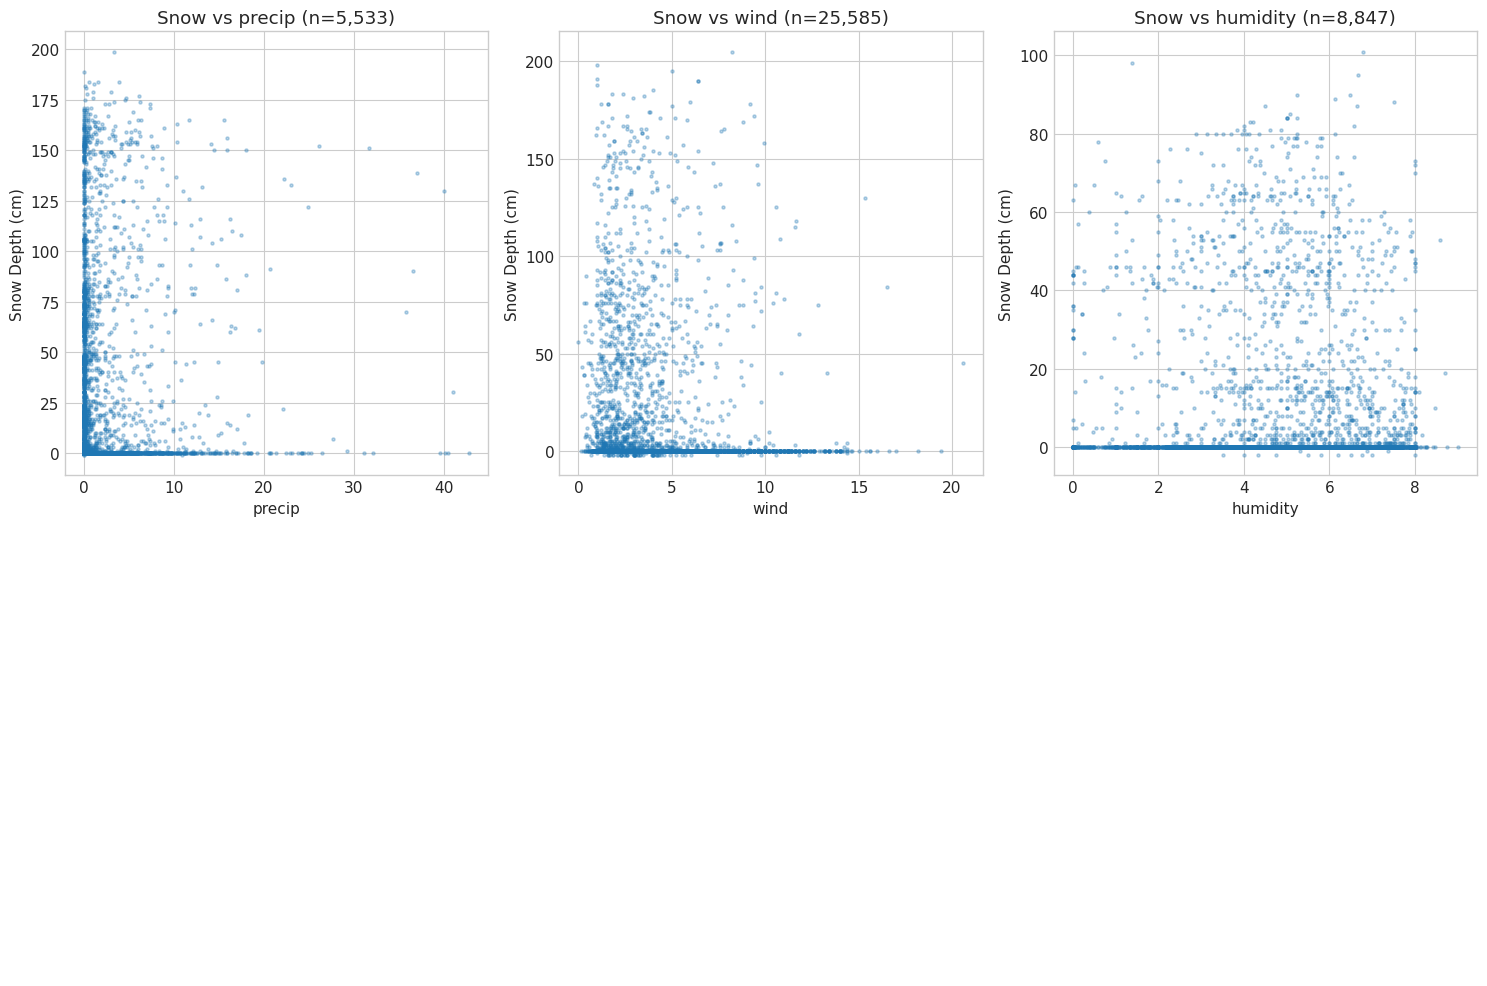

In [22]:
# Pairwise relationships with snow (for columns with data)
cols_with_data = [col for col in param_cols if col != 'snow' and df[col].notna().sum() > 1000]

if len(cols_with_data) > 0:
    n_cols = min(len(cols_with_data), 6)
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(cols_with_data[:6]):
        # Get data where both columns are not null
        mask = df['snow'].notna() & df[col].notna()
        if mask.sum() > 100:
            sample_idx = np.random.choice(np.where(mask)[0], min(5000, mask.sum()), replace=False)
            axes[i].scatter(df.loc[sample_idx, col], df.loc[sample_idx, 'snow'] * 100, alpha=0.3, s=5)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Snow Depth (cm)')
            axes[i].set_title(f'Snow vs {col} (n={mask.sum():,})')
        else:
            axes[i].text(0.5, 0.5, f'Not enough\noverlapping data\nfor {col}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'Snow vs {col}')
    
    # Hide empty subplots
    for i in range(len(cols_with_data), 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No other parameters have sufficient data for correlation with snow.")

## 8. Anomaly Detection (Extreme Events)

In [23]:
# Identify extreme snow events
if 'snow_cm' not in df.columns:
    df['snow_cm'] = df['snow'] * 100

# Define thresholds for extreme events
snow_99 = df['snow_cm'].quantile(0.99)
snow_95 = df['snow_cm'].quantile(0.95)

print(f"Snow Depth Percentiles:")
print(f"  95th percentile: {snow_95:.1f} cm")
print(f"  99th percentile: {snow_99:.1f} cm")
print(f"  Maximum: {df['snow_cm'].max():.1f} cm")

# Extreme events
extreme_snow = df[df['snow_cm'] > snow_99].copy()
print(f"\nExtreme snow events (>99th percentile): {len(extreme_snow):,}")

Snow Depth Percentiles:
  95th percentile: 57.0 cm
  99th percentile: 91.0 cm
  Maximum: 229.0 cm

Extreme snow events (>99th percentile): 15,480


In [24]:
# Show top extreme events
if len(extreme_snow) > 0:
    print("\nTop 20 Extreme Snow Events:")
    top_events = extreme_snow.nlargest(20, 'snow_cm')[['date', 'station_name', 'latitude', 'longitude', 'elevation', 'snow_cm']]
    display(top_events)


Top 20 Extreme Snow Events:


,date,station_name,latitude,longitude,elevation,snow_cm
561144,2020-03-31,Katterjåkk,68.4207,18.167,513.911,229.0
561145,2020-04-01,Katterjåkk,68.4207,18.167,513.911,229.0
561143,2020-03-30,Katterjåkk,68.4207,18.167,513.911,226.0
561146,2020-04-02,Katterjåkk,68.4207,18.167,513.911,226.0
561147,2020-04-03,Katterjåkk,68.4207,18.167,513.911,224.0
561152,2020-04-15,Katterjåkk,68.4207,18.167,513.911,222.0
561153,2020-04-16,Katterjåkk,68.4207,18.167,513.911,222.0
561151,2020-04-10,Katterjåkk,68.4207,18.167,513.911,221.0
561154,2020-04-17,Katterjåkk,68.4207,18.167,513.911,221.0
561150,2020-04-09,Katterjåkk,68.4207,18.167,513.911,219.0



Records with daily snow change > 20 cm: 2,472


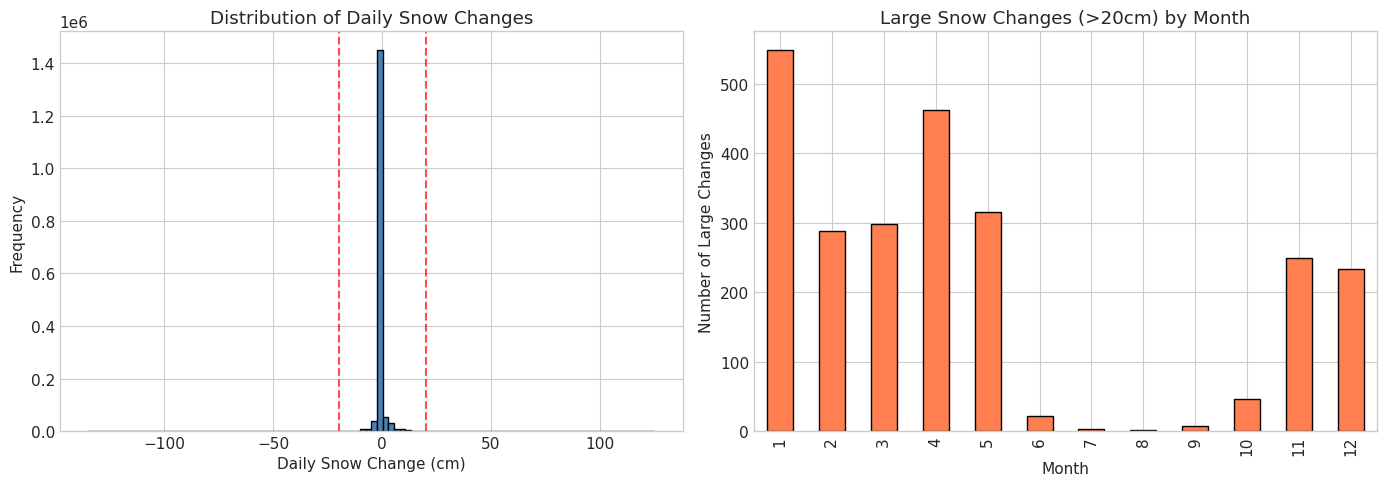

In [25]:
# Daily snow change (potential anomalies)
df_sorted = df.sort_values(['station_id', 'date'])
df_sorted['snow_change'] = df_sorted.groupby('station_id')['snow_cm'].diff()

# Large daily changes
large_changes = df_sorted[abs(df_sorted['snow_change']) > 20].copy()
print(f"\nRecords with daily snow change > 20 cm: {len(large_changes):,}")

if len(large_changes) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Distribution of daily changes
    df_sorted['snow_change'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Daily Snow Change (cm)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Daily Snow Changes')
    axes[0].axvline(20, color='red', linestyle='--', alpha=0.7)
    axes[0].axvline(-20, color='red', linestyle='--', alpha=0.7)
    
    # Large changes by month
    large_changes['month'] = large_changes['date'].dt.month
    large_changes.groupby('month').size().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Number of Large Changes')
    axes[1].set_title('Large Snow Changes (>20cm) by Month')
    
    plt.tight_layout()
    plt.show()

## 9. Data Quality Summary

In [26]:
print("=" * 80)
print("DATA QUALITY SUMMARY")
print("=" * 80)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total records: {len(df):,}")
print(f"   - Total stations: {df['station_id'].nunique()}")
print(f"   - Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   - Parameters: {len(param_cols)}")

print(f"\n2. PARAMETER COVERAGE:")
for col in param_cols:
    coverage = df[col].notna().mean() * 100
    status = "OK" if coverage > 50 else "LOW" if coverage > 10 else "VERY LOW"
    print(f"   - {col}: {coverage:.1f}% [{status}]")

print(f"\n3. KEY FINDINGS:")
high_coverage = [col for col in param_cols if df[col].notna().mean() > 0.5]
low_coverage = [col for col in param_cols if df[col].notna().mean() < 0.1]
print(f"   - Parameters with good coverage (>50%): {high_coverage if high_coverage else 'NONE'}")
print(f"   - Parameters with poor coverage (<10%): {low_coverage if low_coverage else 'NONE'}")

print(f"\n4. RECOMMENDATIONS:")
print(f"   - Focus on parameters with >50% coverage for model training")
print(f"   - Consider downloading parameters separately (different station coverage)")
print(f"   - May need to find stations that have multiple parameters available")

DATA QUALITY SUMMARY

1. DATASET OVERVIEW:
   - Total records: 1,616,151
   - Total stations: 659
   - Date range: 2015-01-01 to 2025-10-01
   - Parameters: 4

2. PARAMETER COVERAGE:
   - snow: 100.0% [OK]
   - precip: 0.3% [VERY LOW]
   - wind: 1.6% [VERY LOW]
   - humidity: 0.5% [VERY LOW]

3. KEY FINDINGS:
   - Parameters with good coverage (>50%): ['snow']
   - Parameters with poor coverage (<10%): ['precip', 'wind', 'humidity']

4. RECOMMENDATIONS:
   - Focus on parameters with >50% coverage for model training
   - Consider downloading parameters separately (different station coverage)
   - May need to find stations that have multiple parameters available


In [27]:
# Find stations with best multi-parameter coverage
station_param_coverage = df.groupby('station_name')[param_cols].apply(lambda x: x.notna().any()).sum(axis=1)
best_stations = station_param_coverage.sort_values(ascending=False).head(20)

print("\nStations with Most Parameters Available:")
print(best_stations)


Stations with Most Parameters Available:
station_name
Norrköping-SMHI                   4
Abisko Aut                        4
Arjeplog A                        4
Såtenäs                           3
Linköping-Malmslätt               3
Ronneby-Bredåkra                  3
Luleå-Kallax Flygplats            3
Svenska Högarna                   3
Enköping                          3
Falsterbo                         3
Katterjåkk A                      3
Vidsel                            3
Uppsala Aut                       2
Katterjåkk                        2
Stockholm-Observatoriekullen A    2
Stockholm-Observatoriekullen      2
Rätan                             1
Råneå                             1
Räfsebo D                         1
Rödupp                            1
dtype: int64


In [28]:
# Save summary statistics to CSV
summary_df = pd.DataFrame({
    'Parameter': param_cols,
    'Total_Records': [df[col].notna().sum() for col in param_cols],
    'Coverage_Pct': [df[col].notna().mean() * 100 for col in param_cols],
    'Zero_Count': [(df[col] == 0).sum() for col in param_cols],
    'Min': [df[col].min() for col in param_cols],
    'Max': [df[col].max() for col in param_cols],
    'Mean': [df[col].mean() for col in param_cols],
    'Std': [df[col].std() for col in param_cols],
})

summary_df = summary_df.sort_values('Coverage_Pct', ascending=False)
summary_df.to_csv('../data/raw/smhi_13param_summary.csv', index=False)
print("Summary saved to: ../data/raw/smhi_13param_summary.csv")
print("\n")
display(summary_df)

Summary saved to: ../data/raw/smhi_13param_summary.csv




,Parameter,Total_Records,Coverage_Pct,Zero_Count,Min,Max,Mean,Std
0,snow,1616151,100.000000,1222863,-0.02,2.29,0.080094,0.200128
2,wind,25585,1.583082,12,0.00,20.60,4.123071,2.676332
3,humidity,8847,0.547412,94,0.00,9.00,4.729502,1.845116
1,precip,5533,0.342357,2876,0.00,76.30,1.584981,3.878356


## 10. Next Steps

Based on the data exploration:

1. **Data Quality Issues**:
   - Many parameters have low coverage (not all stations measure all parameters)
   - Need to either: (a) use only high-coverage parameters, or (b) download parameters separately and find overlapping stations

2. **For Model Training**:
   - Focus on stations/dates where multiple parameters are available
   - Consider imputation strategies for missing values
   - Snow depth has good coverage and shows clear seasonal patterns

3. **Recommended Actions**:
   - Download parameters separately to maximize coverage
   - Create a merged dataset with only stations having core parameters
   - Implement data preprocessing pipeline to handle missing values